In [1]:
from src.objetos import Dados, camada_densa, rede_neural

In [2]:
caminho_dados = r"dados/imageMNIST.csv"
caminho_rotulos = r"dados/labelMNIST.csv"

In [3]:
dados = Dados(caminho_dados=caminho_dados, caminho_rotulos=caminho_rotulos)

In [4]:
epocas = 500
taxa_aprendizado = 2
lambda_reg = 1
# [A,B,C] : A -> B -> C
arquitetura_camadas = [400, 25, 10]
tamanho_holdout = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

In [5]:
import numpy as np
import pandas as pd

custos_treino = []
custos_teste = []

for i in tamanho_holdout:
    dados._holdout(i)

    camadas = []

    for i in range(len(arquitetura_camadas)-2):
        camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[i], 
            tamanho_saida=arquitetura_camadas[i+1],
            funcao_de_ativacao='sigmoid'
            )
        camadas.append(camada)
    # Aplica softmax na ultima camada
    camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[-2], 
            tamanho_saida=arquitetura_camadas[-1],
            funcao_de_ativacao='softmax'
            )
    camadas.append(camada)

    rede = rede_neural.RedeNeural(camadas=camadas,funcao_de_custo="entropia_cruzada", regularizador_lambda=lambda_reg)

    rede.treinar(
        epocas=epocas,
        taxa_aprendizado=taxa_aprendizado,
        conjunto_treinamento=dados.conjunto_treinamento,
        conjunto_validacao=dados.conjunto_validacao,
        regularizador_lambda=lambda_reg
    )

    logs_atual = pd.read_csv("log_treinamento.csv")
    custo_treino = logs_atual['custo_treino_sem_reg'].iloc[-1]
    y_pred_teste = rede._avalia(dados.conjunto_teste[0])
    custo_teste = rede._calcula_custo(dados.conjunto_teste[1],y_pred_teste)

    custos_treino.append(custo_treino)
    custos_teste.append(custo_teste)

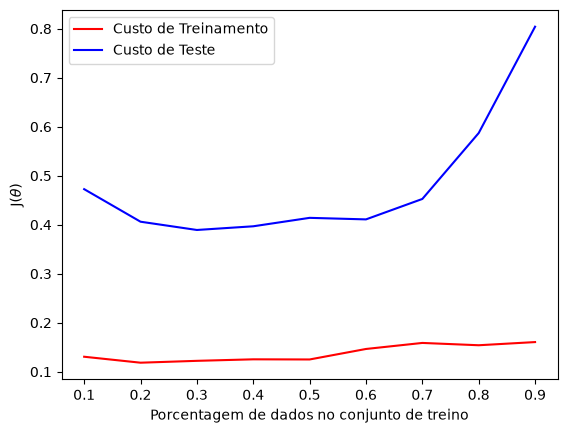

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(tamanho_holdout,custos_treino, label='Custo de Treinamento', color='red')
plt.plot(tamanho_holdout,custos_teste, label='Custo de Teste', color='blue')
plt.xlabel(r"Porcentagem de dados no conjunto de treino")
plt.ylabel(r"J($\theta$)")
plt.legend()
plt.show()